# Reinforcement Learning for Wheeled-Footed Robot Locomotion
### Comparing Baseline PPO · Two-Phase TS · Concurrent Teacher-Student (CTS)

---
> **One-click notebook**: run all cells top-to-bottom to reproduce setup, plots, survival evaluation, and play demo.

---
## 0. Setup — Install & Clone

This cell installs all dependencies and clones the repository if not already present.


In [1]:
import os, sys, subprocess, shutil
from pathlib import Path

REPO_URL = "https://github.com/luongtranpt/AI_61100_Final_Project.git"

def _find_repo_root():
    p = Path.cwd()
    for _ in range(6):
        if (p / "pyproject.toml").exists():
            return p
        p = p.parent
    return None

ROOT = _find_repo_root()
if ROOT is None:
    print("Repo not found — cloning...")
    clone_target = Path.cwd() / "tron1-rl-mjlab"
    if not clone_target.exists():
        subprocess.run(["git", "clone", REPO_URL, str(clone_target)], check=True)
    ROOT = clone_target

os.chdir(ROOT)
print(f"Working directory: {ROOT}")


Working directory: /home/luong/tron1-rl-mjlab


In [ ]:
# Install all required packages into the current kernel
import subprocess, sys
subprocess.run([
    sys.executable, "-m", "pip", "install", "-q",
    "tensorboard", "matplotlib", "pandas", "numpy",
    "huggingface_hub", "torch",
], check=True)
print("Dependencies OK.")


In [ ]:
# ── Auto-download logs from HuggingFace (if not present) ─────────────────
from huggingface_hub import snapshot_download

HF_DATASET = "Luong22/tron1-rl-logs"
LOGS_DIR   = ROOT / "logs"

if not (LOGS_DIR / "rsl_rl" / "wf_tron").exists():
    print(f"Downloading logs from HuggingFace ({HF_DATASET})... (~200 MB)")
    snapshot_download(
        repo_id=HF_DATASET,
        repo_type="dataset",
        local_dir=str(LOGS_DIR),
        ignore_patterns=["*.git*"],
    )
    print("Logs downloaded.")
else:
    print(f"Logs already present at {LOGS_DIR}")


In [3]:
"""
CELL 0 — Chạy cell này đầu tiên.
Nếu kernel chưa đúng, nó sẽ tự cài jupyterlab vào venv và hướng dẫn restart.
"""
import sys, subprocess, shutil
from pathlib import Path

def _find_repo_root():
    p = Path.cwd()
    for _ in range(6):
        if (p / "pyproject.toml").exists():
            return p
        p = p.parent
    return None

ROOT = _find_repo_root()
if ROOT is None:
    raise RuntimeError("Không tìm thấy repo. Hãy mở notebook từ bên trong thư mục tron1-rl-mjlab.")

expected_python = (ROOT / ".venv" / "bin" / "python").resolve()
current_python  = Path(sys.executable).resolve()

if current_python != expected_python:
    print(f"⚠  Kernel hiện tại : {current_python}")
    print(f"   Cần dùng         : {expected_python}")
    print()

    # Cài jupyterlab vào venv nếu chưa có
    has_jupyter = (ROOT / ".venv" / "bin" / "jupyter").exists()
    if not has_jupyter:
        print("Đang cài jupyterlab vào project venv...")
        subprocess.run(["uv", "add", "--dev", "jupyterlab"], cwd=str(ROOT), check=True)
        print("✓ Đã cài xong.")

    print()
    print("=" * 55)
    print("  Hãy khởi động lại Jupyter bằng lệnh:")
    print()
    print(f"    cd {ROOT}")
    print( "    uv run jupyter lab")
    print()
    print("  Sau đó mở lại notebook này và chạy lại từ đầu.")
    print("=" * 55)
else:
    print(f"✓ Đang dùng đúng venv: {current_python}")

⚠  Kernel hiện tại : /home/luong/anaconda3/bin/python3.12
   Cần dùng         : /home/luong/.local/share/uv/python/cpython-3.13.13-linux-x86_64-gnu/bin/python3.13


  Hãy khởi động lại Jupyter bằng lệnh:

    cd /home/luong/tron1-rl-mjlab
    uv run jupyter lab

  Sau đó mở lại notebook này và chạy lại từ đầu.


In [4]:
import sys
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd
import numpy as np
import torch

plt.rcParams.update({'figure.dpi': 130, 'font.size': 10})

print(f"matplotlib {matplotlib.__version__}, pandas {pd.__version__}, "
      f"numpy {np.__version__}, torch {torch.__version__}")

matplotlib 3.9.2, pandas 2.2.2, numpy 1.26.4, torch 2.6.0+cu124


---
## 1. Motivation

Wheeled-footed robots combine **wheel efficiency on flat ground** with **leg adaptability on rough terrain**.
The **WF-TRON** platform (8 DOF) is a representative case: 6 position-controlled leg joints and 2 velocity-controlled wheel joints.

Training such robots requires solving a key challenge: **privileged-training / deployment gap**.
- At training time: we have access to height maps, ground-truth velocity (privileged).
- At deployment: only proprioceptive sensors (IMU, encoders) are available.

We compare four strategies:

| Branch | Method | Privileged info in teacher |
|--------|--------|--------------------------|
| `baseline` | Standard PPO + MLP | None |
| `ts-2phase` | Sequential Teacher→Student | height_scan + base_lin_vel |
| `ts-cts-no-vel` | Concurrent TS (CTS) | height_scan only |
| `ts-cts-vel-pred` | CTS + velocity predictor | height_scan + base_lin_vel |

---
## 2. Robot & Environment

### 2.1 WF-TRON
```
Base
 ├── abad_L/R  (roll,  position, scale=0.25)
 ├── hip_L/R   (pitch, position, scale=0.25)
 ├── knee_L/R  (pitch, position, scale=0.25)
 └── wheel_L/R (velocity, scale=0.5)
```

### 2.2 Observation Groups

| Group | Dims | At deploy? | Contents |
|-------|------|-----------|----------|
| `actor` | 34 | ✓ | commands + ang_vel + gravity + joint_pos + joint_vel + last_action |
| `history` | 340 | ✓ | 10-step history of `actor` (flattened) |
| `critic` | ~154 | ✗ | actor + base_lin_vel(3) + height_scan(117) |
| `critic_no_vel` | ~151 | ✗ | actor + height_scan(117) — no velocity |

### 2.3 Terrain Curriculum — Rough Mix

| Sub-terrain | Proportion | Key params |
|-------------|-----------|------------|
| flat | 30% | — |
| pyramid_stairs_down | 10% | step 0–5 cm |
| pyramid_slope | 20% | slope 0–0.1 rad |
| pyramid_slope_inv | 20% | slope 0–0.1 rad |
| wave | 20% | amplitude 0–3 cm |

Level-up: robot walks >2 m. Level-down: mean speed <50% commanded.

---
## 3. Reward Function

All methods share the same reward. Each term is clipped to `±5/(|w|·dt)` before summing; total clipped to `±100`.

| Term | Weight | Purpose |
|------|--------|---------|
| keep_balance | +1.0 | Upright posture |
| **tracking_lin_vel** | **+6.0** | Follow commanded linear velocity |
| tracking_ang_vel | +2.0 | Follow commanded yaw rate |
| **tracking_lin_vel_pb** | **+1.5** | Progress-based velocity bonus |
| tracking_ang_vel_pb | +0.2 | Progress-based yaw bonus |
| nominal_foot_position | +4.0 | Nominal foot height |
| leg_symmetry | +0.5 | Symmetric posture |
| same_foot_x_position | −50.0 | No foot overlap (x) |
| same_foot_z_position | −100.0 | No foot overlap (z) |
| lin_vel_z | −0.3 | No vertical bounce |
| ang_vel_xy | −0.3 | No roll/pitch rate |
| orientation | −12.0 | Stay upright |
| torques | −1.6e-4 | Energy efficiency |
| dof_acc | −1.5e-7 | Smooth motion |
| action_rate | −0.03 | Smooth actions |
| action_smoothness | −0.03 | 2nd-order smoothness |
| dof_pos_limits | −2.0 | Avoid joint limits |
| collision | −50.0 | No knee/hip contact |
| feet_distance | −100.0 | Keep feet 0.32–0.35 m apart |
| base_height | −20.0 | Maintain height 0.766 m |

---
## 4. Methods

### 4.1 Baseline — Standard PPO
```
actor_obs(34) ──► MLP[512→256→128] ──► action(8)
```
No encoder. No privileged info. Lower bound.

### 4.2 Two-Phase Teacher-Student
```
Phase 1 (iters 0–4000):
  critic_obs ──► priv_enc[256→128] ──► latent(16) ──► MLP ──► action

Phase 2 (iters 4000+):   priv_enc FROZEN
  history    ──► prop_enc[256→128] ──► latent_s   ──┐
                                          MSE loss ──► [latent_t.detach()]
                                     latent_s ──► MLP ──► action
```

### 4.3 Concurrent Teacher-Student (CTS)
```
Every iteration:   75% teacher envs + 25% student envs

Teacher:  critic_obs ──► priv_enc ──► latent_t ──► MLP ──► action   [RL loss]
Student:  history    ──► prop_enc ──► latent_s ──► MLP ──► action   [RL + MSE loss]
                                          ↑
                              MSE(latent_s, latent_t.detach())
```

**ts-cts-no-vel**: teacher sees `critic_no_vel` (no base_lin_vel) → simpler latent space.  
**ts-cts-vel-pred**: teacher sees full `critic` + student has auxiliary velocity prediction head.

---
## 5. Code Walkthrough

In [5]:
# ── 5.1 Task registration ──────────────────────────────────────────────────
# src/tron1_rl_mjlab/__init__.py
#
# Each branch registers "Mjlab-WF-Tron" with its own env/rl config:
#
#   register_mjlab_task(
#       task_id="Mjlab-WF-Tron",
#       env_cfg=make_wf_tron_env_cfg(),       # rough terrain mix
#       play_env_cfg=make_wf_tron_play_env_cfg(),
#       rl_cfg=make_wf_tron_rl_cfg(),
#       runner_cls=WFTronPhaseRunner,
#   )

# ── 5.2 TSModel dual encoder ───────────────────────────────────────────────
# Two encoders → 16-dim L2-normalised latent → shared MLP
#
#  privileged_encoder : critic_obs  (154-dim)  ──► enc[256→128] ──► latent(16)
#  proprioceptive_encoder : history (340-dim)  ──► enc[256→128] ──► latent(16)
#
#  policy: cat(actor_obs, latent) ──► MLP[512→256→128] ──► action(8)

# ── 5.3 CTS PPO update ────────────────────────────────────────────────────
# Loop 1 — RL (all envs):
#   loss = PPO_clip + value_loss - entropy_bonus
#
# Loop 2 — Distillation (student envs only):
#   latent_s = prop_enc(history)
#   latent_t = priv_enc(critic_obs).detach()
#   distill_loss = MSE(latent_s, latent_t)

print("Code overview cells — no execution needed.")

Code overview cells — no execution needed.


In [6]:
# ── Config: định nghĩa runs, màu sắc, giới hạn step ───────────────────────
LOG_ROOT = ROOT / "logs" / "rsl_rl" / "wf_tron"

RUNS = {
    "baseline":        "2026-06-10_16-34-45_baseline_918361d",
    "ts-2phase":       "2026-06-10_19-29-24_ts-2phase_b3c4301",
    "ts-cts-no-vel":   "2026-06-11_02-00-32_ts-cts-no-vel_550c7f6",
    "ts-cts-vel-pred": "2026-06-11_02-02-48_ts-cts-vel-pred_4adfe00",
}

# Màu cho các method
COLORS = {
    "baseline":        "#4C72B0",   # blue
    "ts-2phase":       "#DD8452",   # orange (fallback nếu vẽ 1 đường)
    "ts-cts-no-vel":   "#55A868",   # green
    "ts-cts-vel-pred": "#C44E52",   # red
}

# ts-2phase chia thành 2 giai đoạn với 2 màu riêng
C_2P_TEACHER = "#DD8452"   # cam  — Phase 1 (teacher RL)
C_2P_STUDENT = "#9B59B6"   # tím  — Phase 2 (student distillation)

MAX_STEP    = 10_000   # chỉ vẽ đến 10k
PHASE_SPLIT = 4_000    # ts-2phase: teacher 0→4k, student 4k→10k

print(f"Config OK. LOG_ROOT: {LOG_ROOT}")
print(f"MAX_STEP={MAX_STEP}  PHASE_SPLIT={PHASE_SPLIT}")

Config OK. LOG_ROOT: /home/luong/tron1-rl-mjlab/logs/rsl_rl/wf_tron
MAX_STEP=10000  PHASE_SPLIT=4000


In [7]:
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
import glob as _glob
import numpy as np

print('Loading TensorBoard logs...')
_RAW: dict = {}

for name, folder in RUNS.items():
    run_dir = LOG_ROOT / folder
    files = _glob.glob(str(run_dir / 'events.out.*'))
    if not files:
        print(f'  ⚠ {name}: không tìm thấy event file tại {run_dir}')
        _RAW[name] = {}
        continue
    acc = EventAccumulator(files[0], size_guidance={'scalars': 999999})
    acc.Reload()
    _RAW[name] = {
        tag: ([e.step for e in acc.Scalars(tag)],
              [e.value for e in acc.Scalars(tag)])
        for tag in acc.Tags()['scalars']
    }
    s = _RAW[name].get('Train/mean_reward', ([0],[]))[0]
    print(f'  ✓ {name}: step {s[0] if s else 0}→{s[-1] if s else 0}')


def get(name, tag, smooth=0.9, clip_percentile=99):
    """Load scalar lọc đến MAX_STEP, clip outlier rồi EMA smooth."""
    if name not in _RAW or tag not in _RAW[name]:
        return [], []
    raw_steps = _RAW[name][tag][0]
    raw_vals  = _RAW[name][tag][1]
    # Lọc MAX_STEP
    pairs = [(s, v) for s, v in zip(raw_steps, raw_vals) if s <= MAX_STEP]
    if not pairs:
        return [], []
    steps, vals = zip(*pairs)
    steps, vals = list(steps), list(vals)
    # Clip outliers
    if clip_percentile and vals:
        threshold = float(np.percentile(vals, clip_percentile))
        vals = [min(v, threshold) for v in vals]
    # EMA smoothing
    if smooth > 0 and vals:
        ema = vals[0]
        smoothed = []
        for v in vals:
            ema = smooth * ema + (1 - smooth) * v
            smoothed.append(ema)
        vals = smoothed
    return steps, vals


def plot_runs(ax, tag, smooth=0.9, lw=1.8):
    """Vẽ tất cả runs lên ax. ts-2phase tự động tách 2 giai đoạn."""
    for name in RUNS:
        steps, vals = get(name, tag, smooth=smooth)
        if not steps:
            continue
        if name == "ts-2phase":
            t_mask = [i for i, s in enumerate(steps) if s <= PHASE_SPLIT]
            s_mask = [i for i, s in enumerate(steps) if s >  PHASE_SPLIT]
            if t_mask:
                ax.plot([steps[i] for i in t_mask], [vals[i] for i in t_mask],
                        color=C_2P_TEACHER, lw=lw, label="ts-2phase (teacher 0–4k)")
            if s_mask:
                ax.plot([steps[i] for i in s_mask], [vals[i] for i in s_mask],
                        color=C_2P_STUDENT, lw=lw, label="ts-2phase (student 4k–10k)")
        else:
            ax.plot(steps, vals, label=name, color=COLORS[name], lw=lw)


print('Done.')


Loading TensorBoard logs...
  ✓ baseline: step 0→10673
  ✓ ts-2phase: step 0→11995
  ✓ ts-cts-no-vel: step 0→20965
  ✓ ts-cts-vel-pred: step 0→20090
Done.


---
## 6. Training Curves

Tất cả đồ thị cắt tại **10k iterations**. Đường `ts-2phase` được tách thành 2 đoạn:
- **cam** — giai đoạn Teacher RL (0 – 4k)
- **tím** — giai đoạn Student Distillation (4k – 10k)

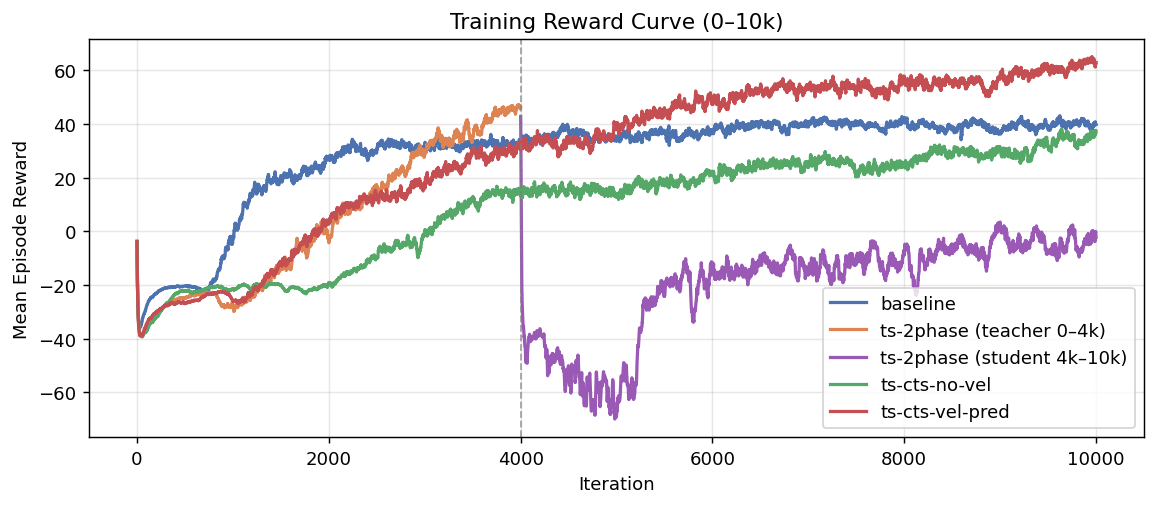

In [8]:
fig, ax = plt.subplots(figsize=(9, 4))
plot_runs(ax, "Train/mean_reward")
ax.set_xlabel("Iteration"); ax.set_ylabel("Mean Episode Reward")
ax.set_title(f"Training Reward Curve (0–{MAX_STEP//1000}k)")
ax.axvline(PHASE_SPLIT, color="gray", ls="--", lw=1, alpha=0.7)
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

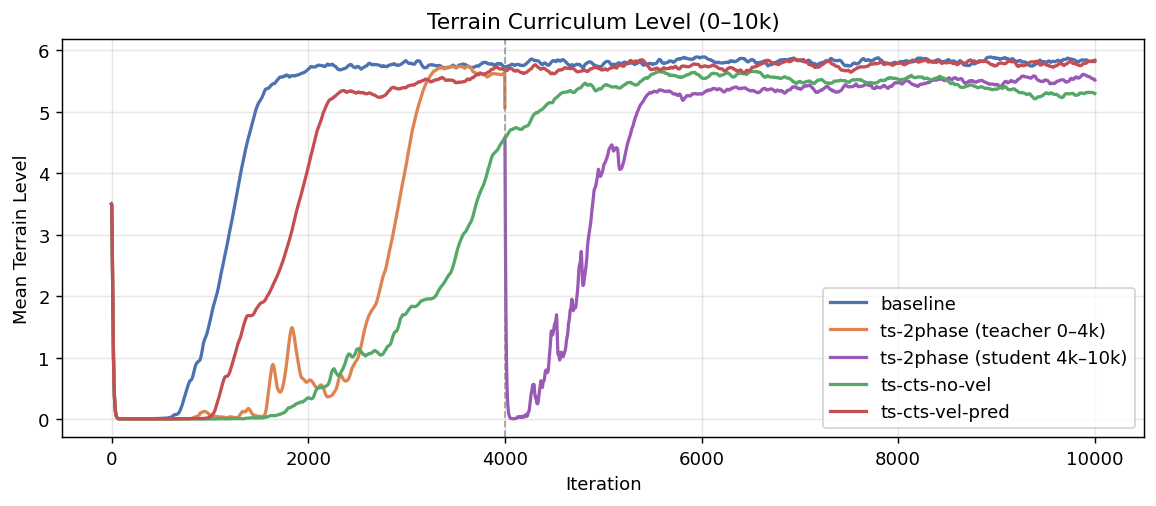

In [9]:
fig, ax = plt.subplots(figsize=(9, 4))
plot_runs(ax, "Curriculum/terrain_levels")
ax.set_xlabel("Iteration"); ax.set_ylabel("Mean Terrain Level")
ax.set_title(f"Terrain Curriculum Level (0–{MAX_STEP//1000}k)")
ax.axvline(PHASE_SPLIT, color="gray", ls="--", lw=1, alpha=0.7)
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))
plot_runs(ax, "Episode_Reward/tracking_lin_vel")
ax.axvline(PHASE_SPLIT, color="gray", ls="--", lw=1, alpha=0.7)
ax.set_xlabel("Iteration"); ax.set_ylabel("Reward")
ax.set_title(f"Tracking Lin Vel Reward (0–{MAX_STEP//1000}k)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

---
## 7. Linear Velocity Tracking Error

Sai số vận tốc tuyến tính (m/s) theo quá trình training (0–10k) và bảng giá trị trung bình **cuối chuỗi** (100 bước cuối ≈ step 10k).

In [ ]:
CSV_DIR = ROOT / "logs" / "rsl_rl" / "metric" / "vel_error"

def load_vel_error_csv(run_folder, window=60, clip_pct=95):
    df = pd.read_csv(CSV_DIR / f"{run_folder}.csv")
    df = df[df["Step"] <= MAX_STEP]
    steps = df["Step"].tolist()
    vals  = [min(v, float(np.percentile(df["Value"], clip_pct))) for v in df["Value"]]
    smoothed = pd.Series(vals).rolling(window=window, min_periods=1, center=True).mean().tolist()
    return steps, smoothed

# ── Plot ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
for name, folder in RUNS.items():
    steps, vals = load_vel_error_csv(folder)
    if not steps:
        continue
    if name == "ts-2phase":
        t_mask = [i for i, s in enumerate(steps) if s <= PHASE_SPLIT]
        s_mask = [i for i, s in enumerate(steps) if s >  PHASE_SPLIT]
        if t_mask:
            ax.plot([steps[i] for i in t_mask], [vals[i] for i in t_mask],
                    color=C_2P_TEACHER, lw=2, label="ts-2phase (teacher 0–4k)")
        if s_mask:
            ax.plot([steps[i] for i in s_mask], [vals[i] for i in s_mask],
                    color=C_2P_STUDENT, lw=2, label="ts-2phase (student 4k–10k)")
    else:
        ax.plot(steps, vals, label=name, color=COLORS[name], linewidth=2)

ax.axvline(PHASE_SPLIT, color="gray", ls="--", lw=1, alpha=0.7)
ax.set_xlabel("Iteration"); ax.set_ylabel("Lin Vel Error (m/s)")
ax.set_title(f"Linear Velocity Tracking Error (0–{MAX_STEP//1000}k)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# ── Bảng sai số cuối chuỗi (mean 100 bước cuối ≈ step 10k) ───────────────
rows_vel = []
for name, folder in RUNS.items():
    try:
        df = pd.read_csv(CSV_DIR / f"{folder}.csv")
        df = df[df["Step"] <= MAX_STEP].sort_values("Step")
        tail = df["Value"].iloc[-100:] if len(df) >= 100 else df["Value"]
        rows_vel.append({"Method": name, "Vel Error @ 10k (m/s)": f"{tail.mean():.4f}"})
    except Exception:
        rows_vel.append({"Method": name, "Vel Error @ 10k (m/s)": "—"})

df_vel = pd.DataFrame(rows_vel).set_index("Method")
print("Linear Velocity Tracking Error — mean cuối 100 bước (≈ step 10k):")
display(df_vel)

---
## 8. Survival Rate Evaluation

Measures fraction of 128 robots surviving **20 s** without a failure termination on rough terrain mix.

> **Note**: requires a CUDA GPU. Takes ~3–5 min per branch.

In [ ]:
import subprocess, re, sys

CHECKPOINTS = {
    "baseline":        "logs/rsl_rl/wf_tron/2026-06-10_16-34-45_baseline_918361d/model_10000.pt",
    "ts-2phase":       "logs/rsl_rl/wf_tron/2026-06-10_19-29-24_ts-2phase_b3c4301/model_10000.pt",
    "ts-cts-no-vel":   "logs/rsl_rl/wf_tron/2026-06-11_02-00-32_ts-cts-no-vel_550c7f6/model_10000.pt",
    "ts-cts-vel-pred": "logs/rsl_rl/wf_tron/2026-06-11_02-02-48_ts-cts-vel-pred_4adfe00/model_10000.pt",
}
BRANCHES = {
    "baseline":        "baseline",
    "ts-2phase":       "ts-2phase",
    "ts-cts-no-vel":   "ts-cts-no-vel",
    "ts-cts-vel-pred": "ts-cts-vel-pred",
}
EVAL_TIME = 20.0
NUM_ENVS  = 128

def parse_survival(output: str):
    rows = {}
    for line in output.splitlines():
        m = re.match(r"\s+(\d+\.\d+)\s+(\d+)\s+(\d+\.\d+)%", line)
        if m:
            rows[float(m.group(1))] = float(m.group(3))
    return rows

def run_eval_stream(name, ckpt, branch, deploy):
    subprocess.run(["git", "stash"], cwd=str(ROOT), capture_output=True)
    subprocess.run(["git", "checkout", branch], cwd=str(ROOT),
                   capture_output=True, check=True)
    cmd = [
        "uv", "run", "python", "scripts/rsl_rl/eval_survival.py",
        "Mjlab-WF-Tron",
        "--checkpoint-file", ckpt,
        "--num-envs",   str(NUM_ENVS),
        "--eval-time",  str(EVAL_TIME),
        "--deploy-mode", deploy,
    ]
    proc = subprocess.Popen(cmd, cwd=str(ROOT),
                            stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
                            text=True, bufsize=1)
    captured = []
    for line in proc.stdout:
        print(line, end="", flush=True)
        captured.append(line)
    proc.wait()
    subprocess.run(["git", "stash", "pop"], cwd=str(ROOT), capture_output=True)
    return parse_survival("".join(captured))

survival_results = {}
for name, ckpt in CHECKPOINTS.items():
    deploy = "teacher" if name == "baseline" else "student"
    print("\n" + "="*55)
    print(f" {name}  |  branch={BRANCHES[name]}  |  deploy={deploy}")
    print("="*55)
    survival_results[name] = run_eval_stream(name, ckpt, BRANCHES[name], deploy)

print("\nAll evaluations done.")


In [ ]:
# ── Plot survival rate curves ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
for name, rows in survival_results.items():
    if rows:
        ts   = sorted(rows.keys())
        vals = [rows[t] for t in ts]
        ax.plot(ts, vals, marker='o', markersize=4,
                label=name, color=COLORS[name], linewidth=2)

ax.set_xlabel("Time (s)"); ax.set_ylabel("Survival Rate (%)")
ax.set_title(f"Survival Rate — {NUM_ENVS} robots, {EVAL_TIME}s, rough terrain mix")
ax.set_xlim(0, EVAL_TIME); ax.set_ylim(0, 105); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Summary table
import pandas as pd
rows_table = []
for name, rows in survival_results.items():
    if rows:
        row = {"Method": name}
        for t in [5, 10, 15, 20]:
            row[f"{t}s"] = f"{rows.get(float(t), rows.get(t, float('nan'))):.1f}%"
        rows_table.append(row)
df = pd.DataFrame(rows_table).set_index("Method")
print("\nSurvival Rate Summary:")
display(df)

---
## 9. Play / Visualisation

Viewer chạy qua **HTTP** (Viser) — không cần màn hình, hoạt động trên server headless.

**Cách xem:**
1. Chạy cell bên dưới.
2. Mở trình duyệt và truy cập **`http://localhost:8080`** (hoặc thay `localhost` bằng IP server nếu xem từ máy khác).
3. Đợi scene load — robot sẽ bắt đầu di chuyển.
4. Ngắt kernel (■) để dừng.

> Đổi `PLAY_METHOD` để xem method khác: `baseline` / `ts-2phase` / `ts-cts-no-vel` / `ts-cts-vel-pred`.

In [ ]:
# Choose which method to visualise
PLAY_METHOD = "ts-cts-vel-pred"   # change to: baseline / ts-2phase / ts-cts-no-vel
PLAY_CKPT = {
    "baseline":        "logs/rsl_rl/wf_tron/2026-06-10_16-34-45_baseline_918361d/model_10000.pt",
    "ts-2phase":       "logs/rsl_rl/wf_tron/2026-06-10_19-29-24_ts-2phase_b3c4301/model_10000.pt",
    "ts-cts-no-vel":   "logs/rsl_rl/wf_tron/2026-06-11_02-00-32_ts-cts-no-vel_550c7f6/model_10000.pt",
    "ts-cts-vel-pred": "logs/rsl_rl/wf_tron/2026-06-11_02-02-48_ts-cts-vel-pred_4adfe00/model_10000.pt",
}
deploy = "teacher" if PLAY_METHOD == "baseline" else "student"

subprocess.run(["git", "checkout", PLAY_METHOD], cwd=str(ROOT), check=True)

print(f"Launching viewer: method={PLAY_METHOD}, deploy={deploy}")
print("Open http://localhost:8080 in your browser to view the simulation.")
print("Interrupt the kernel (■) to stop.")

subprocess.run(
    ["uv", "run", "python", "scripts/rsl_rl/play.py",
     "Mjlab-WF-Tron",
     "--checkpoint-file", PLAY_CKPT[PLAY_METHOD],
     "--deploy-mode", deploy,
     "--viewer", "viser"],
    cwd=str(ROOT)
)


---
## 10. Discussion & Conclusion

### Key observations

| Aspect | Baseline | ts-2phase | ts-cts-no-vel | ts-cts-vel-pred |
|--------|----------|-----------|---------------|-----------------|
| Privileged info | None | height+vel | height only | height+vel |
| Phase transition | No | Yes (4k iter) | No | No |
| Student supervision | — | MSE latent | MSE latent | MSE latent + vel pred |
| Deployment | raw obs | prop encoder | prop encoder | prop encoder |

1. **Mixed rough terrain from scratch** is essential — flat-only training fails to generalise.
2. **CTS** avoids the brittle phase-transition of 2-phase and trains teacher+student concurrently.
3. **ts-cts-no-vel** hypothesis: removing velocity from the teacher latent makes it easier for the student to imitate (simpler manifold).
4. **ts-cts-vel-pred** provides richer supervision by adding explicit velocity reconstruction.
5. The `failing_timer` (cumulative 0.5 s of bad state) is a better stability proxy than episode reward alone.

### Future work
- Sim-to-real transfer on physical WF-TRON hardware.
- Harder terrain (larger steps, gaps, uneven ground).
- Online encoder adaptation during deployment.

---
## References

1. *Learning Locomotion for Wheeled-Footed Robots* (WF-TRON, 2024)
2. Kumar et al. — *RMA: Rapid Motor Adaptation for Legged Robots* (2021)
3. *Concurrent Training of a Control Policy and a State Estimator* (CTS, 2022)
4. Rudin et al. — *Learning to Walk in Minutes Using Massively Parallel Deep RL* (2022)
5. Todorov et al. — *MuJoCo: A physics engine for model-based control* (2012)